In [4]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from get_ddf import get_ddf_df
from data_handling import *
import statsmodels.api as sm
import sys 
from scipy.optimize import minimize
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/ddf/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

site_dict = {
    'kahiltna':['K17b','K14k','K53'], # KAHILTNA     'KPS',
    'kennicott':['GTH','KC31','GTL'], # KENNICOTT
    'gulkana':['AU','B','D'], # GULKANA
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C','D'], # LEMON CREEK
    'taku':['MG1','NWB1','TKG3'], # TAKU
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def find_kp(k, ds, bmeas, starts, ends):
    acc_mod = []
    add_mod = []
    for start, end in zip(starts, ends):
        acc_mod.append(ds.sel(time=slice(start, end)).accum.sum().values)
        refreeze = ds.sel(time=slice(start, end)).refreeze.sum().values
        melt = -1*ds.sel(time=slice(start, end)).melt.sum().values
        add_mod.append(refreeze + melt)
    acc_mod = np.array(acc_mod)
    add_mod = np.array(add_mod)
    
    objective = np.mean(np.abs((acc_mod * k + add_mod) - np.array(bmeas)))
    return objective

all_albedo = {'mod':[], 'meas':[]}
for glacier in site_dict:
    site_fn = f'../data/by_glacier/{glacier}/site_constants.csv'
    site_df = pd.read_csv(site_fn, index_col=0)
    if 'kp' not in site_df.columns:
        site_df['kp'] = site_df['lat'].copy() * np.nan

    for site in site_dict[glacier]:
        mb = MassBalance(glacier, site, use='benchmark')
        ds = xr.open_dataset(base_fp + f'{glacier}{site}_2026_02_26_base_0.nc')

        # mb.get_model_mb(ds)
        # mb.plot_mb()
        # albedo = Albedo(glacier, site)
        # albedo.get_model_albedo(ds)
        # albedo.plot_timeseries()
        # for mod, meas in zip(albedo.mod, albedo.meas):
        #     all_albedo['mod'].append(mod)
        #     all_albedo['meas'].append(meas)

        if mb.dataset == 'seasonal':
            mb.get_model_mb(ds)
            starts = mb.period_starts[mb.idx_winter]
            ends = mb.period_ends[mb.idx_winter]
            bw_meas = mb.meas[mb.idx_winter]
            
            result = minimize(find_kp,1,
                                      method='L-BFGS-B',bounds=((0, 5),),
                                      args=(ds, bw_meas, starts, ends))
            kp = result.x[0]
            site_df.loc[site, 'kp'] = kp

            bw_mod = []
            bw_mod_kp = []
            for start, end in zip(starts, ends):
                acc = ds.sel(time=slice(start, end)).accum.sum().values
                refreeze = ds.sel(time=slice(start, end)).refreeze.sum().values
                melt = -1*ds.sel(time=slice(start, end)).melt.sum().values
                bw_mod.append(acc + refreeze + melt)
                bw_mod_kp.append(acc*kp + refreeze + melt)

            print(glacier, site, kp)
            # plt.figure(figsize=(3,3))
            # plt.plot(pd.to_datetime(ends).year, bw_meas, 'k', label='Measured')
            # plt.plot(pd.to_datetime(ends).year, bw_mod, 'k--', label='Modeled')
            # plt.plot(pd.to_datetime(ends).year, bw_mod_kp, 'r', label=f'Model with kp {kp:.3f}')
            # plt.title(glacier+' '+site)
            # plt.legend()
            # plt.show()
    # site_df.to_csv(site_fn)

kahiltna K17b 0.7023414238186757
kahiltna K53 1.7068888637879764
kennicott GTH 1.6634793010179634
kennicott KC31 1.130154191842188
kennicott GTL 1.0094549347163355
gulkana AU 2.0588026401017103
gulkana B 2.710018518732716
gulkana D 3.1900623202381246
wolverine N 0.9877200957743191
wolverine B 1.1477651719827946
wolverine EC 1.981469475081177
lemon_creek B 1.4230809067903878
lemon_creek C 1.5168359512504206
lemon_creek D 1.5903339881579404


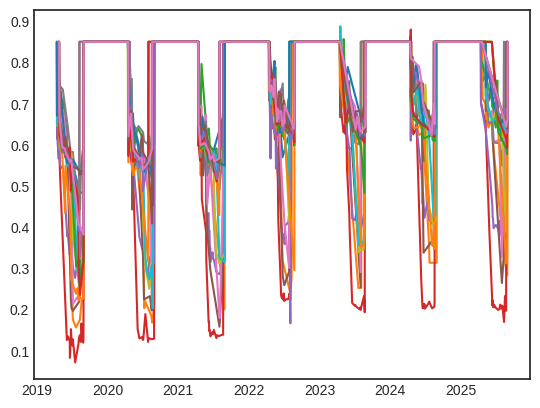

In [56]:
for glacier in site_dict:
    for site in site_dict[glacier]:
        albedo = Albedo(glacier, site)
        if len(np.where(~np.isnan(albedo.data))[0]) < 10:
            continue

        df_all = None
        for year in np.unique(pd.to_datetime(albedo.time).year):
            idx_year = np.where(pd.to_datetime(albedo.time).year == year)[0]
            df = pd.DataFrame({'albedo': albedo.data.flatten()[idx_year]}, 
                          index=pd.to_datetime(albedo.time)[idx_year])
            df.index = pd.to_datetime(df.index).normalize()
            df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='D'))
            df = df.interpolate(method='time')

            df.index = pd.DatetimeIndex(df.index)
            
            df.loc[df.index.min() - pd.Timedelta(days=1),'albedo'] = 0.85
            df.loc[df.index.max() + pd.Timedelta(days=1),'albedo'] = 0.85
            df = df.sort_index()

            if df_all is None:
                df_all = df 
            else:
                df_all = pd.concat([df_all, df])

        df_all = df_all.reindex(pd.date_range(df_all.index[0], df_all.index[-1]))
        df_all = df_all.interpolate(method='time')
        df_hourly = df.resample('h').ffill().sort_index()
        plt.plot(df_all.index, df_all['albedo'])
        # print(df_all)
        df_all.to_csv(home_fp + f'climate_data/AWS/albedo/{glacier}{site}_S2albedo.csv')
        # assert 1==0

/tmp/ipykernel_127354/1523039872.py:11: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(fn)


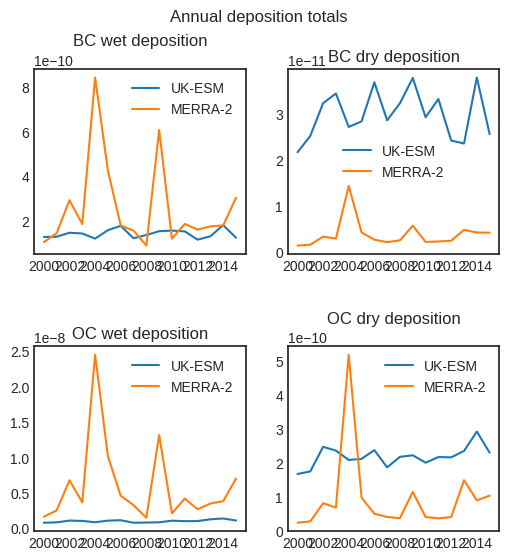

In [2]:
climate_fp = '/trace/group/rounce/cvwilson/climate_data/UKESM/'

deptype = 'wet'
species = 'BC'

fig, axes = plt.subplots(2, 2, figsize=(6, 6), gridspec_kw={'hspace':0.5, 'wspace':0.2})

for axrow, species in zip(axes, ['BC','OC']):
    for ax, deptype in zip(axrow, ['wet','dry']):
        fn = climate_fp + f'dr401_GFED/sum_{species.lower()}_{deptype}deposition_kgm-2s-1.nc'
        ds = xr.open_dataset(fn)
        for var in list(ds.variables):
            if 'tendency' in var:
                vuse = var 

        ds = ds[vuse].sel(latitude=63.259091,longitude=-145.428586,method='nearest')
        ds = ds.sel(time=slice('2000-01-01','2025-01-01'))

        depmerra = 'WT' if deptype == 'wet' else 'DP'
        dsm = xr.open_dataarray(f'../../climate_data/MERRA2/63.5_-145.6/{species}{depmerra}002_63.5_-145.6.nc')
        dsm = dsm.sel(time=ds.time.values + pd.Timedelta(minutes=30))

        resample = 'YS'
        ds = ds.resample(time=resample).sum()
        dsm = dsm.resample(time=resample).sum()

        ax.plot(ds.time.values, ds.values, label='UK-ESM')
        ax.plot(dsm.time.values, dsm.values, label='MERRA-2')
        ax.legend()
        max_val = np.max([ds.values, dsm.values])
        # ax.plot([0, max_val], [0, max_val], 'k--')
        # ax.scatter(dsm.values, ds.values)
        ax.set_title(f'{species} {deptype} deposition')
fig.suptitle('Annual deposition totals')
# fig.supxlabel('MERRA-2')
# fig.supylabel('UK-ESM')
plt.show()

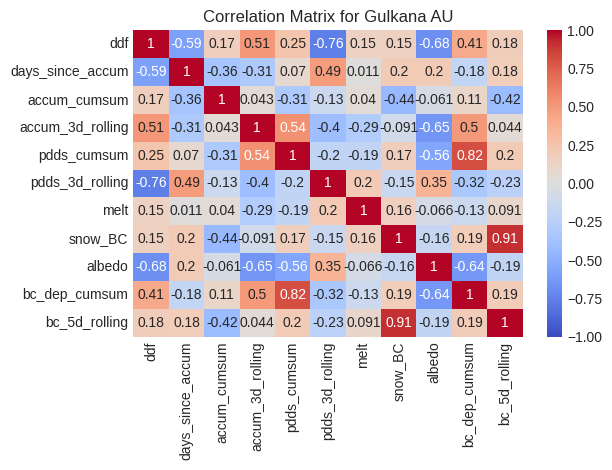

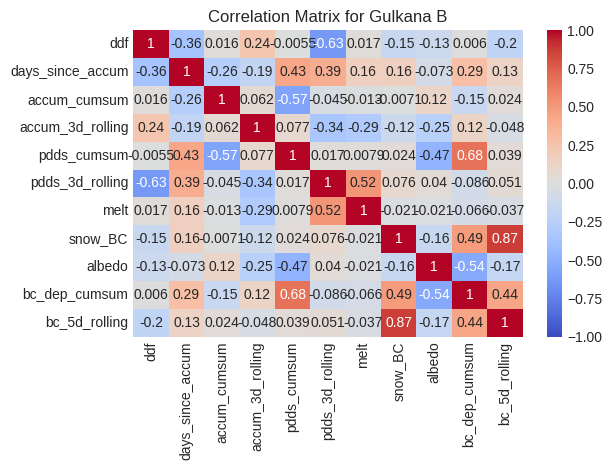

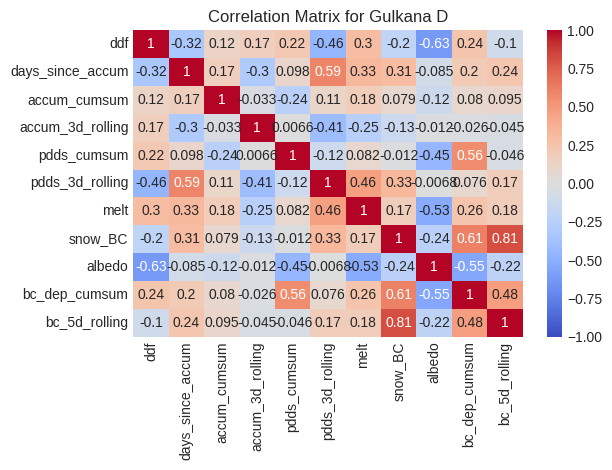

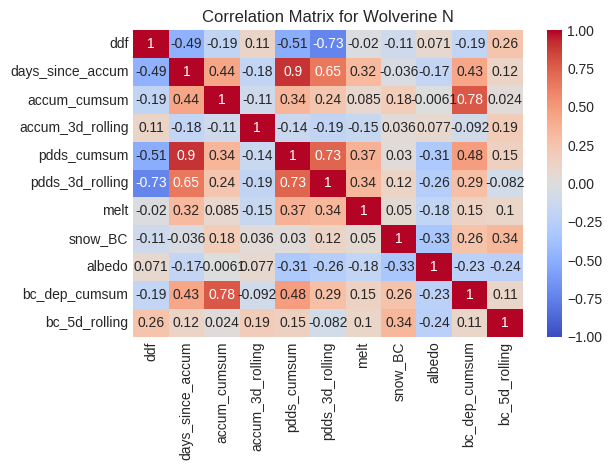

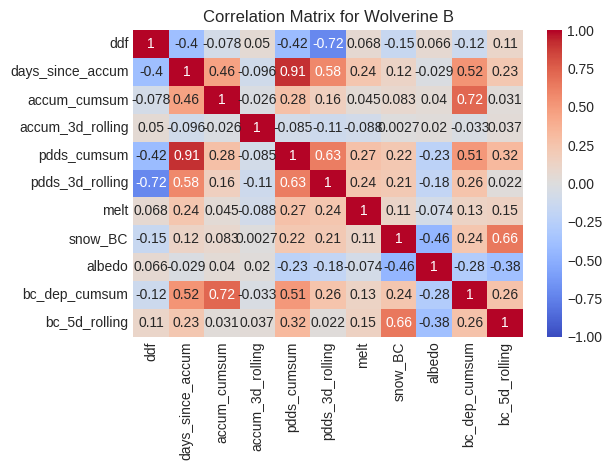

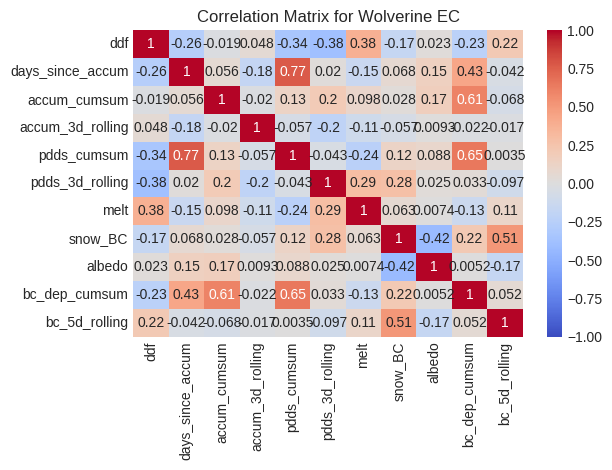

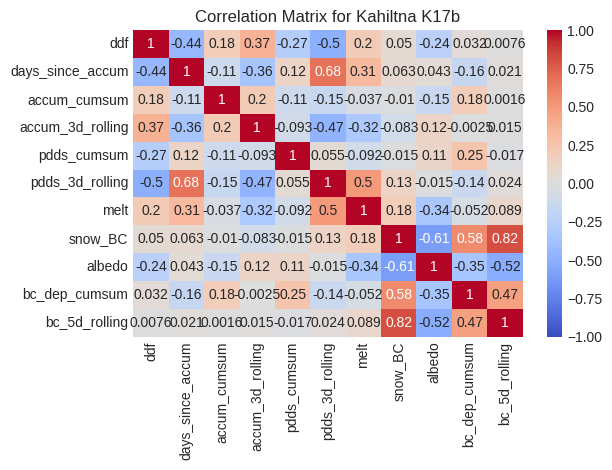

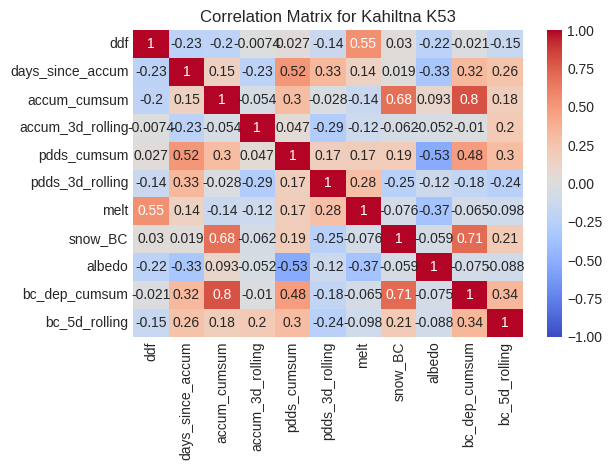

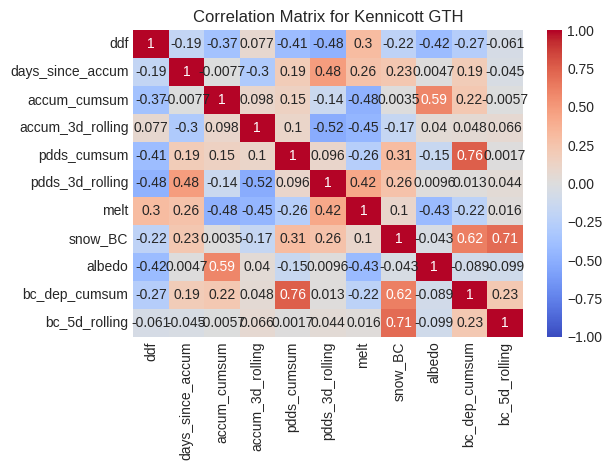

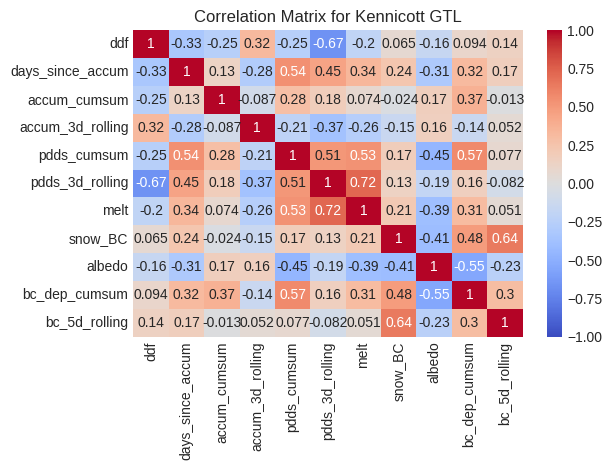

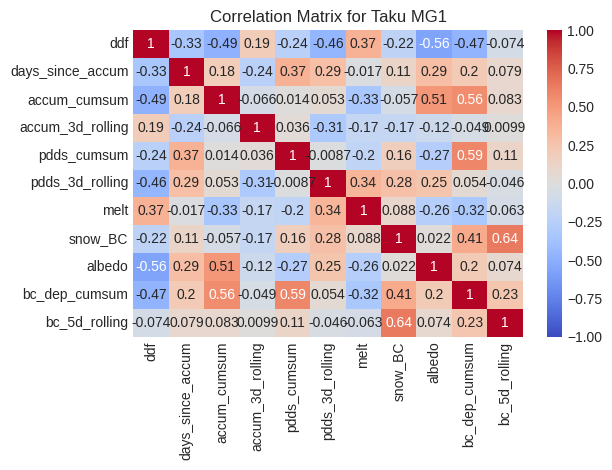

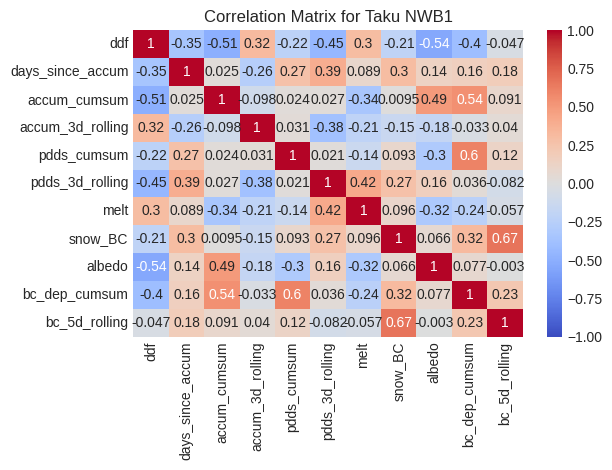

In [49]:
acceptable = {
    'gulkana':{'AU':'gulkanaAU_2026_02_03_base_long_0.nc',
               'B':'gulkanaB_2026_02_03_base_long_0.nc',
               'D':'gulkanaD_2026_02_03_base_long_0.nc',
               },
    'wolverine':{'N':'wolverineN_2026_02_12_base_qmwindkp1_0.nc',
                 'B':'wolverineB_2026_02_17_base_qmwolvkp2_0.nc',
                 'EC':'wolverineEC_2026_02_12_base_qmwindkp1_0.nc',
                 },
    'kahiltna':{'K17b':'kahiltnaK17b_2026_02_13_base_qmwindkp0.5_0.nc',
                 'K53':'kahiltnaK53_2026_02_12_base_qmwindkp2_0.nc',
                 },
    'kennicott':{'GTH':'kennicottGTH_2026_02_12_base_qmwindkp1_0.nc',
                 'GTL':'kennicottGTL_2026_02_13_base_qmwindkp0.5_0.nc',
                 },
    'taku':{'MG1':'takuMG1_2026_02_12_base_qmwindkp1_0.nc',
            'NWB1':'takuNWB1_2026_02_12_base_qmwindkp1_0.nc',
            }
}
coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemoncreek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}

all_df = None
for glacier in acceptable:
    coords = coord_dict[glacier]
    ds_bcd = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds_bcw = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']
    for site in acceptable[glacier]:
        ds = xr.open_dataset(base_fp + glacier+site+'_2026_02_25_base_0.nc') # acceptable[glacier][site])
        out = base_fp+f'{glacier}{site}_df.csv'
        df = get_ddf_df(ds, ds_bc, plot_corr=True, n_rolling_bc=5, n_rolling_pdds=3, output_fn=out, savefig=True)
        df['glacier'] = [glacier] * len(df.index)
        df['glaciersite'] = [glacier + site] * len(df.index)
        if all_df is not None:
            all_df = pd.concat([all_df, df])
        else:
            all_df = df

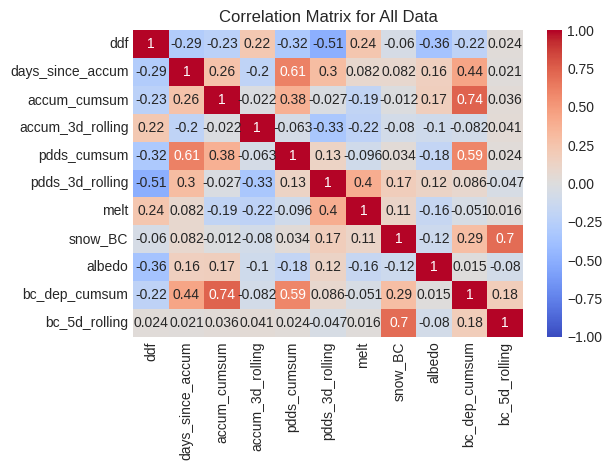

In [51]:
corr = all_df.drop(columns=['glacier','glaciersite']).corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f'Correlation Matrix for All Data')
plt.tight_layout()
plt.show()

In [ ]:
cats = all_df['glaciersite'].astype('category').cat.categories
codes = all_df['glaciersite'].astype('category').cat.codes

# pick a colormap with enough distinct colors
base_cmap = plt.cm.get_cmap('Dark2', len(cats))
cmap = mpl.colors.ListedColormap(base_cmap.colors)

plt.scatter(
    all_df['pdds_3d_rolling'],
    all_df['ddf'],
    c=codes,
    cmap=cmap
)

# legend
for code, name in enumerate(cats):
    plt.scatter([], [], color=cmap(code), label=name)

plt.legend(title='Glacier')
plt.show()


In [ ]:
glacier = 'gulkana'
site = 'B'
data = SnowMelt(glacier, site)
ds = xr.open_dataset(base_fp + f'{glacier}{site}_2026_02_03_base_long_0.nc')
data.get_model_snow(ds)
error = data.model_error_metric(data.mod_melt, data.sar_melt['med'], data.time, transition_type='onset')
print('Melt onset MAE:',error,'days')

error = data.model_error_metric(data.mod_snow, data.sar_snow['med'], data.time, transition_type='offset')
print('Snowline MAE:',error,'days')

In [ ]:
data.plot_snow_bool()
data.plot_melt_bool()

In [ ]:
#comparing quantile mapping approaches
# ds_lemon = xr.open_dataset(base_fp + 'takuTKG3_2026_02_15_base_qmlemonkp2_0.nc')
# ds_gulk = xr.open_dataset(base_fp + 'takuTKG3_2026_02_12_base_qmallkp2_0.nc')

coords = '58.5_-134.3'
for var in ['wind','temp','rh']:
    if var == 'wind':
        dsu = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/U2M_{coords}.nc')['U2M']
        dsv = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/V2M_{coords}.nc')['V2M']
        ds_clim = np.sqrt(np.square(dsu.values) + np.square(dsv.values))
    elif var == 'rh':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/RH2M_{coords}.nc')['RH2M'].values
    elif var == 'temp':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/T2M_{coords}.nc')['T2M'].values - 273.15
    varn = var if var != 'temp' else 'temp_0'
    df_gulk = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_gulkana_{varn}.csv')
    df_lem = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_lemon_creek_{varn}.csv')
        
    # interpolate values according to quantile mapping
    values = ds_clim
    adj_gulk = np.interp(values, df_gulk['sorted'], df_gulk['mapping'])
    adj_lem = np.interp(values, df_lem['sorted'], df_lem['mapping'])

    # plt.scatter(adj_gulk, adj_lem, s=5, alpha=0.5)
    plt.scatter(values, adj_lem, s=5, alpha=0.5,label='lemon')
    plt.scatter(values, adj_gulk, s=5, alpha=0.5,label='gulkana')
    minn = np.min([adj_gulk, adj_lem])
    maxx = np.max([adj_gulk, adj_lem])
    plt.ylabel('Original MERRA-2') # Lemon Creek adjusted')
    plt.xlabel('Adjusted') # Gulkana adjusted')
    plt.plot([minn,maxx],[minn,maxx],'k--')
    plt.legend()
    plt.title(var)
    plt.show()

In [ ]:
target = 'ddf'
df = pd.read_csv(base_fp + 'gulkanaB_ddf.csv')
fig, axes = plt.subplots(len(df.columns[1:]) // 2, 2, figsize=(8, 8),
                       gridspec_kw = {'hspace':0.5})
axes = axes.flatten()
for c, col in enumerate(df.columns[1:]):
    data = df[col]
    smoothed = sm.nonparametric.lowess(endog=df[target], exog=df[col], frac=0.2)

    axes[c].scatter(data, df[target], label='data', color='k')
    axes[c].plot(smoothed[:, 0], smoothed[:, 1], c='r', label='smoothed function')
    axes[c].set_title(col)
axes[0].legend()
plt.show()

In [ ]:
ds = xr.open_dataset('../climate_data/MERRA2/BCDP002/MERRA2_BCDP002_gulkana_alltime.nc')
ds2 = xr.open_dataset('../climate_data/MERRA2/BCWT002/MERRA2_BCWT002_gulkana_alltime.nc')
ds['BCDP002'] = ds['BCDP002'] + ds2['BCWT002']
# define time variables
months = ds['time'].dt.month
days = ds['time'].dt.day
# create time mask from apr 1 to sep 30 (inclusive)
mask = ((months > 3) & (months < 10))
ds_season = ds.where(mask, drop=True)
annual_sums = ds_season.groupby('time.year').sum()
plt.plot(annual_sums.year, annual_sums['BCDP002'].values)
plt.axhline(np.quantile(annual_sums['BCDP002'].values, 0.90), c='r')

threshold = np.quantile(annual_sums['BCDP002'].values, 0.90)
base_idx = np.where(annual_sums['BCDP002'].values <= threshold)[0]
fire_idx = np.where(annual_sums['BCDP002'].values > threshold)[0]
plt.scatter(annual_sums.year.values[fire_idx], annual_sums['BCDP002'].values[fire_idx], color='red', marker='*')
plt.show()

fire_years = annual_sums.year.values[fire_idx]
base_years = annual_sums.year.values[base_idx]